### Where is Waldo

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from helpers import plot_sample_images, plot_predictions


import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array, save_img
tf.random.set_seed(42)
np.random.seed(42)

# Report available accelerators
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU acceleration: {len(gpus)} device(s)")
    for gpu in gpus:
        print(f"  {gpu.name}")
else:
    print("No GPU detected — using CPU")

from tensorflow import keras
from keras import Sequential
from keras.layers import (
    Dense, Flatten, Dropout, Conv2D, MaxPooling2D, LSTM, Input
)
from keras.callbacks import EarlyStopping, ModelCheckpoint

# Define image size and batch size
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

#resize all images to 128x128
train_ds = tf.keras.utils.image_dataset_from_directory(
    "data/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)

#rescale pixel values to [0, 1]
from keras.layers import Rescaling

rescale = Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

#confirm rescaling worked
for images, labels in train_ds.take(1):
    print("Pixel value range:", (tf.reduce_min(images).numpy(), tf.reduce_max(images).numpy()))

#start making cnn here no need to further split data


No GPU detected — using CPU
Found 5449 files belonging to 2 classes.
Image batch shape: (32, 128, 128, 3)
Pixel value range: (np.float32(0.0), np.float32(1.0))


In [10]:
#1. Define Model CNN
waldo_cnn = Sequential([
    Input(shape=(128, 128, 3)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation = 'relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') 
]) 

#2. Compile the model
waldo_cnn.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

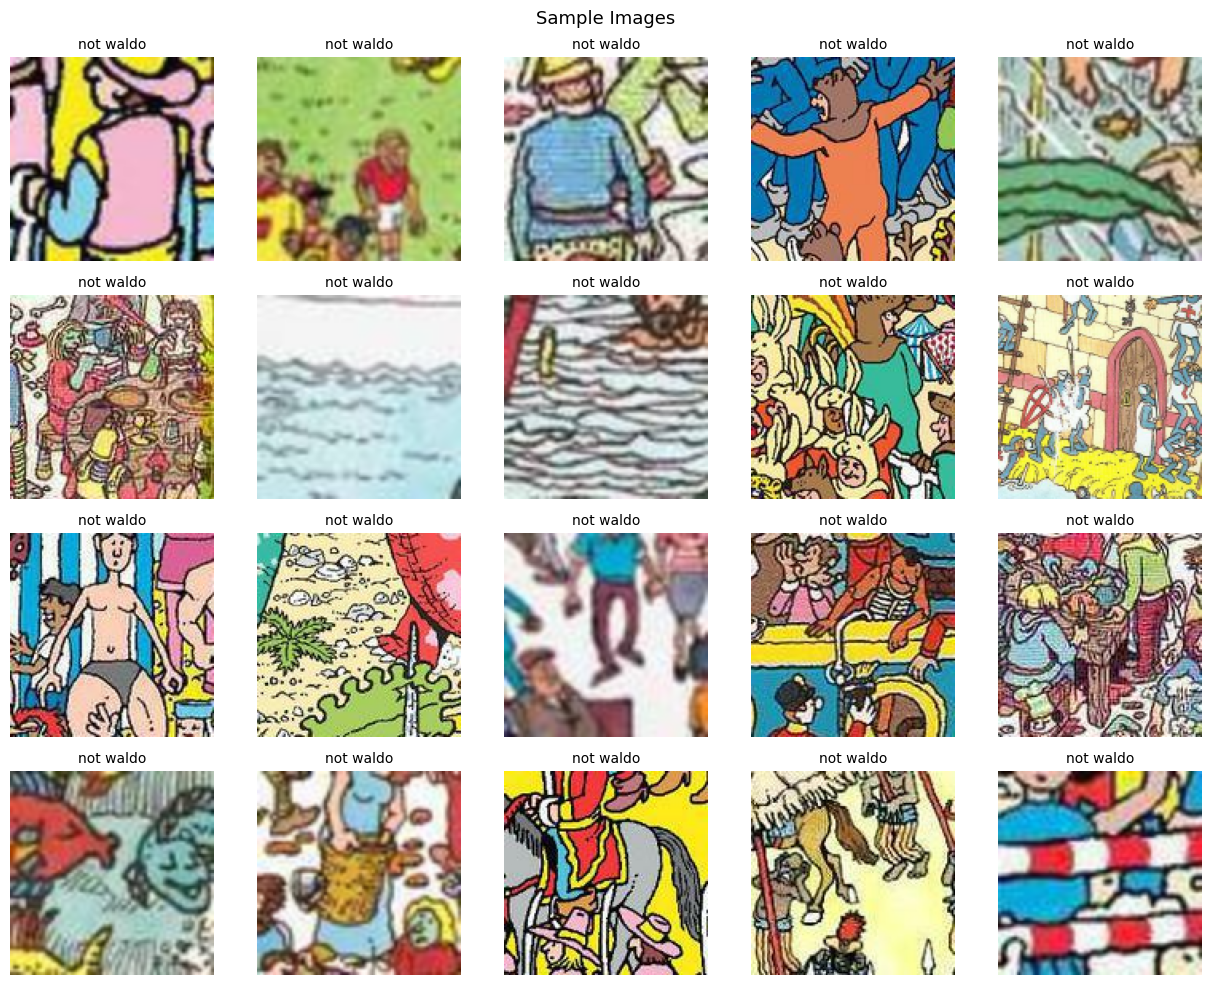

In [11]:
# Test plot_sample_images on the train set
imgs, lbls = next(iter(train_ds))
plot_sample_images(
    imgs.numpy(),
    tf.keras.utils.to_categorical(lbls, 2),
    class_names={0: "not waldo", 1: "waldo"},
    n=20, cols=5
)


In [6]:
#3. Fit the model
history = waldo_cnn.fit(train_ds,
                        epochs=20)

Epoch 1/20


W0000 00:00:1773547251.595413    4130 cpu_allocator_impl.cc:82] Allocation of 65028096 exceeds 10% of free system memory.
W0000 00:00:1773547252.023300    6108 cpu_allocator_impl.cc:82] Allocation of 130056192 exceeds 10% of free system memory.


171/171 ━━━━━━━━━━━━━━━━━━━━ 74s 423ms/step - accuracy: 0.9780 - loss: 0.3927
Epoch 2/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 61s 354ms/step - accuracy: 0.9824 - loss: 0.1033
Epoch 3/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 62s 360ms/step - accuracy: 0.9824 - loss: 0.1096
Epoch 4/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 352ms/step - accuracy: 0.9833 - loss: 0.0854
Epoch 5/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 83s 357ms/step - accuracy: 0.9829 - loss: 0.0725
Epoch 6/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 61s 356ms/step - accuracy: 0.9875 - loss: 0.0518
Epoch 7/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 81s 352ms/step - accuracy: 0.9872 - loss: 0.0463
Epoch 8/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 60s 353ms/step - accuracy: 0.9895 - loss: 0.0330
Epoch 9/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 82s 354ms/step - accuracy: 0.9925 - loss: 0.0250
Epoch 10/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 60s 352ms/step - accuracy: 0.9934 - loss: 0.0176
Epoch 11/20
171/171 ━━━━━━━━━━━━━━━━━━━━ 60s 349ms/step - accuracy: 0.9930 - loss: 0.0181
Epoch 12/20
171/171 ━━━━━━━━━━

In [7]:
# 4. Predict
predictions = waldo_cnn.predict(train_ds)
print(predictions[:5])  # Print the first 5 predictions

171/171 ━━━━━━━━━━━━━━━━━━━━ 17s 98ms/step
[[1.3082989e-05]
 [3.3707482e-05]
 [1.8396703e-04]
 [6.9414396e-06]
 [6.5327855e-04]]


In [8]:
# import test folder and prepare images
# the test directory has unlabeled images so we load with label_mode=None

test_ds = tf.keras.utils.image_dataset_from_directory(
    "data/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode=None,
    shuffle=False
)

test_ds = test_ds.map(lambda x: rescale(x))

# now check to see if the model can predict on test data using the batched dataset
test_predictions = waldo_cnn.predict(test_ds)
print("Test predictions shape:", test_predictions.shape)


Found 19 files.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 401ms/step
Test predictions shape: (19, 1)


In [ ]:
plot_predictions()